importaciones, carga de datos y deficion de variables

In [ ]:
#librerias
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

#1. CARGA DE DATOS Y DEFINICIÓN DE CONSTANTES

datos = np.load("../SolucionReferencia_0000/datos_0000.npz")
X = datos['X']
y = datos['y']
t = datos['t']

N = 256
K = 25
ITERACIONES = 3000
LEARNING_RATE = 0.05

X0 = X[y == 0]
X1 = X[y == 1]
X2 = X[y == 2]

-----------------------FUNCIONES MATEMATICAS Y DE RED--------------------------

Funciones de configuracion (Setup)

In [ ]:
def construir_matriz_fourier(N=256, K=30):
    n = jnp.arange(N)
    filas = []

    for k in range(1, K + 1):
        filas.append(jnp.cos(2 * jnp.pi * k * n / N))
        filas.append(jnp.sin(2 * jnp.pi * k * n / N))

    return (2.0 / N) * jnp.stack(filas)

def coeficientes_fourier_directos(x, K=30):
    N = x.shape[0]
    n = jnp.arange(N)
    coeficientes = []

    for k in range(1, K + 1):
        coef_cos = (2.0 / N) * jnp.sum(x * jnp.cos(2 * jnp.pi * k * n / N))
        coef_sin = (2.0 / N) * jnp.sum(x * jnp.sin(2 * jnp.pi * k * n / N))
        coeficientes.append(coef_cos)
        coeficientes.append(coef_sin)

    return jnp.array(coeficientes)

def inicializar_fourier(key, N=256, K=30):
    W1 = construir_matriz_fourier(N, K)
    W2 = 0.01 * jax.random.normal(key, shape=(N, 2 * K))
    return {"W1": W1, "W2": W2}

def inicializar_aleatoria(key, N=256, K=30):
    key_w1, key_w2 = jax.random.split(key)
    W1 = 0.01 * jax.random.normal(key_w1, shape=(2 * K, N))
    W2 = 0.01 * jax.random.normal(key_w2, shape=(N, 2 * K))
    return {"W1": W1, "W2": W2}


Funciones del modelo y de entrenamiento.

In [ ]:

def red(params, x):
    W1 = params["W1"]
    W2 = params["W2"]
    return W2 @ jnp.tanh(W1 @ x)

red_batch = jax.vmap(red, in_axes=(None, 0))

def perdida(params, X):
    X_hat = red_batch(params, X)
    return jnp.mean((X_hat - X) ** 2)

@jax.jit
def paso_entrenamiento(params, X, learning_rate):
    valor_perdida, gradientes = jax.value_and_grad(perdida)(params, X)
    nuevos_params = jax.tree_util.tree_map(
        lambda parametro, gradiente: parametro - learning_rate * gradiente,
        params,
        gradientes
    )
    return nuevos_params, valor_perdida

def entrenar(params_iniciales, X, y, iteraciones=4000, learning_rate=0.02):
    params = params_iniciales
    X2_local = X[y == 1]  # REVISAR: foco de referencia = regimen 1 (era regimen 2 en el original)

    historial_total = []
    historial_regimen2 = []

    for _ in range(iteraciones):
        params, valor_perdida = paso_entrenamiento(params, X, learning_rate)
        valor_regimen2 = perdida(params, X2_local)

        historial_total.append(float(valor_perdida))
        historial_regimen2.append(float(valor_regimen2))

    return params, np.array(historial_total), np.array(historial_regimen2)


Funciones de evaluacion y analisis.

In [ ]:
def perdida_por_regimen(params, X, y):
    resultados = {}
    for regimen in [0, 1, 2]:
        X_regimen = X[y == regimen]
        resultados[regimen] = float(perdida(params, X_regimen))
    return resultados

def energia_acumulada_coeficientes(x, W_fourier):
    coeficientes = W_fourier @ x
    energia = coeficientes ** 2

    indices = jnp.argsort(energia)[::-1]
    energia_ordenada = energia[indices]
    energia_total = jnp.sum(energia_ordenada)

    acumulada = jnp.where(
        energia_total > 0,
        jnp.cumsum(energia_ordenada) / energia_total,
        jnp.zeros_like(energia_ordenada)
    )

    return coeficientes, indices, acumulada

def coeficientes_para_porcentaje(x, W_fourier, porcentaje=0.90):
    _, _, acumulada = energia_acumulada_coeficientes(x, W_fourier)
    cantidad = jnp.argmax(acumulada >= porcentaje) + 1
    return int(cantidad)

-----------------------FUNCIONES DE GRAFICACION--------------------------

In [ ]:
def graficar_evolucion_perdida(hist_fourier, hist_aleatoria, escala_log=False, titulo="Evolución de la pérdida"):
    plt.figure(figsize=(9, 5))
    funcion_plot = plt.semilogy if escala_log else plt.plot
    
    funcion_plot(hist_fourier, label="Inicialización Fourier")
    funcion_plot(hist_aleatoria, label="Inicialización aleatoria")
    
    plt.xlabel("Iteración")
    plt.ylabel("Error cuadrático medio")
    plt.title(titulo)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def graficar_reconstruccion(t, x_orig, x_fourier, x_aleatoria, indice_regimen=2):
    plt.figure(figsize=(10, 5))
    plt.plot(t, np.array(x_orig), label="Señal original", alpha=0.7)
    plt.plot(t, np.array(x_fourier), label="Reconstrucción Fourier", linestyle="--")
    plt.plot(t, np.array(x_aleatoria), label="Reconstrucción aleatoria", linestyle=":")
    plt.xlabel("Tiempo (s)") # Ajusta la unidad si el enunciado te dio una específica
    plt.ylabel("Amplitud")
    plt.title(f"Reconstrucción de una señal del régimen {indice_regimen}")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def graficar_barras_coeficientes(promedios, porcentaje=90):
    plt.figure(figsize=(7, 5))
    plt.bar(["Régimen 0", "Régimen 1", "Régimen 2"], promedios)
    plt.xlabel("Régimen")
    plt.ylabel("Número promedio de coeficientes")
    plt.title(f"Coeficientes necesarios para alcanzar el {porcentaje} %")
    plt.grid(axis="y")
    plt.tight_layout()
    plt.show()

def graficar_compresion_energia(energia_acum, K_val, porcentaje_ref=0.90):
    plt.figure(figsize=(8, 5))
    plt.plot(np.arange(1, 2 * K_val + 1), np.array(energia_acum))
    plt.axhline(porcentaje_ref, linestyle="--", color="r", label=f"{int(porcentaje_ref*100)} %")
    plt.xlabel("Número de coeficientes")
    plt.ylabel("Fracción de energía acumulada")
    plt.title("Compresión Fourier de una señal del régimen 1")  # REVISAR: ajustado a foco=regimen 1 de la referencia
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

------------------------EJECUCION DEL CODIGO-----------------------

ejecucion de algunas pruebas y cosas no graficas relacionas con el codigo.

In [ ]:
W1_fourier = construir_matriz_fourier(N, K)
x_verificacion = X[0]
coeficientes_capa = W1_fourier @ x_verificacion
coeficientes_directos = coeficientes_fourier_directos(x_verificacion, K)
error_verificacion = float(jnp.max(jnp.abs(coeficientes_capa - coeficientes_directos)))

print("Forma de X:", X.shape)
print("Forma de y:", y.shape)
print("Forma régimen 0:", X0.shape)
print("Forma régimen 1:", X1.shape)
print("Forma régimen 2:", X2.shape)
print("Forma de W1 Fourier:", W1_fourier.shape)
print("Error de verificación Fourier:", error_verificacion)

# Inicialización y entrenamiento
key = jax.random.PRNGKey(1234)
key_fourier, key_aleatoria = jax.random.split(key)

params_fourier_iniciales = inicializar_fourier(key_fourier, N, K)
params_aleatorios_iniciales = inicializar_aleatoria(key_aleatoria, N, K)

params_fourier, historial_fourier, historial_regimen2_fourier = entrenar(
    params_fourier_iniciales, X, y, ITERACIONES, LEARNING_RATE
)

params_aleatorios, historial_aleatorio, historial_regimen2_aleatorio = entrenar(
    params_aleatorios_iniciales, X, y, ITERACIONES, LEARNING_RATE
)

errores_fourier = perdida_por_regimen(params_fourier, X, y)
errores_aleatorios = perdida_por_regimen(params_aleatorios, X, y)

print("\nPérdida final Fourier:", historial_fourier[-1])
print("Pérdida final aleatoria:", historial_aleatorio[-1])
print("Errores por régimen con Fourier:", errores_fourier)
print("Errores por régimen con inicialización aleatoria:", errores_aleatorios)

# Cálculo de reconstrucción y energías para régimen 2
indice_regimen2 = 0
x_original = X1[indice_regimen2]  # REVISAR: foco de referencia = regimen 1
x_reconstruida_fourier = red(params_fourier, x_original)
x_reconstruida_aleatoria = red(params_aleatorios, x_original)

cantidades_por_regimen = {}
for regimen in [0, 1, 2]:
    X_regimen = X[y == regimen]
    cantidades = np.array([
        coeficientes_para_porcentaje(x, W1_fourier, 0.90) for x in X_regimen
    ])
    cantidades_por_regimen[regimen] = cantidades
    print(f"\nRégimen {regimen}: coeficientes necesarios para alcanzar el 90 %")
    print(cantidades)
    print("Promedio:", cantidades.mean())
    print("Mínimo:", cantidades.min())
    print("Máximo:", cantidades.max())

promedios_90 = [  # REVISAR: renombrado variable, ahora corresponde a umbral 90%
    cantidades_por_regimen[0].mean(),
    cantidades_por_regimen[1].mean(),
    cantidades_por_regimen[2].mean()
]

_, _, energia_acumulada = energia_acumulada_coeficientes(x_original, W1_fourier)

Forma de X: (24, 256)
Forma de y: (24,)
Forma régimen 0: (8, 256)
Forma régimen 1: (8, 256)
Forma régimen 2: (8, 256)
Forma de W1 Fourier: (50, 256)
Error de verificación Fourier: 5.960464477539063e-08



Pérdida final Fourier: 0.08383695781230927
Pérdida final aleatoria: 0.08567149937152863
Errores por régimen con Fourier: {0: 0.09424105286598206, 1: 0.09330496191978455, 2: 0.06383699178695679}
Errores por régimen con inicialización aleatoria: {0: 0.0968891978263855, 1: 0.09065462648868561, 2: 0.06934162229299545}



Régimen 0: coeficientes necesarios para alcanzar el 90 %
[4 3 4 5 5 4 3 4]
Promedio: 4.0
Mínimo: 3
Máximo: 5

Régimen 1: coeficientes necesarios para alcanzar el 90 %
[ 5  7 10  3  4  5  5  9]
Promedio: 6.0
Mínimo: 3
Máximo: 10

Régimen 2: coeficientes necesarios para alcanzar el 90 %
[4 4 4 5 6 3 5 4]
Promedio: 4.375
Mínimo: 3
Máximo: 6


ejecucion de graficas

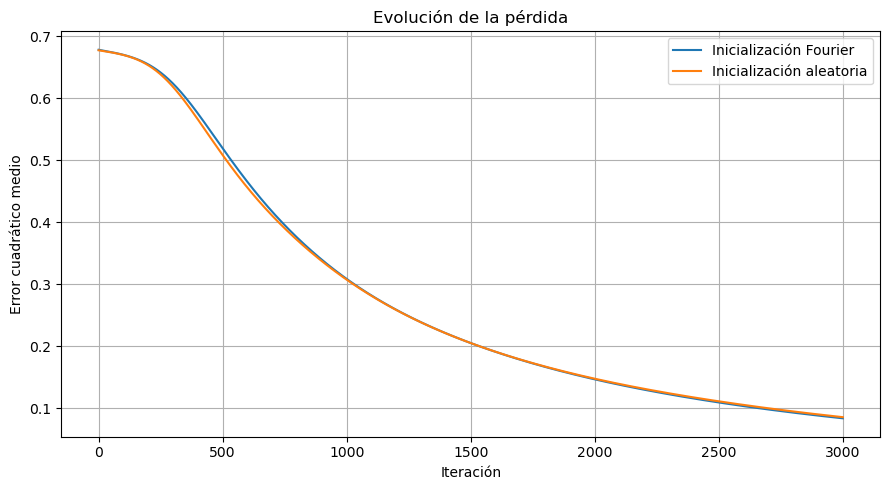

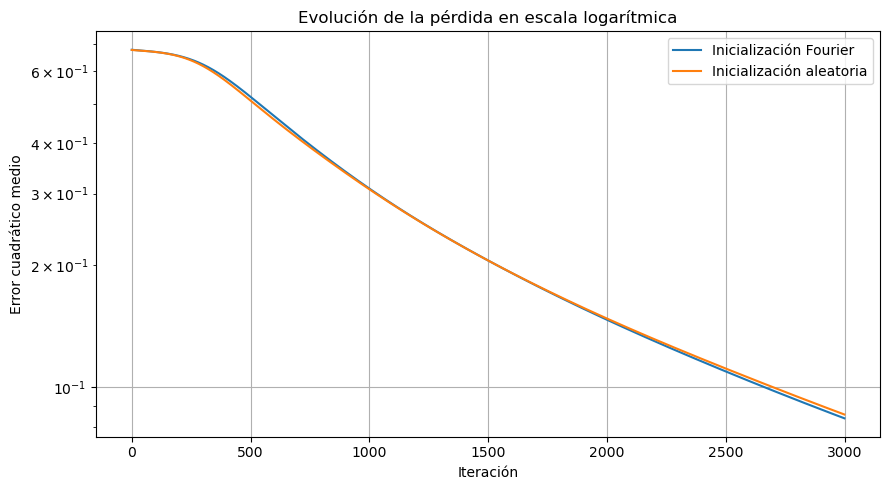

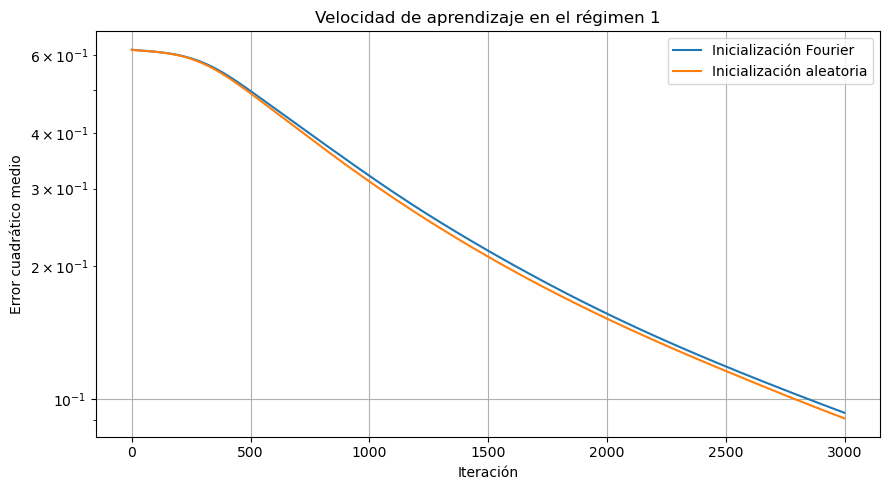

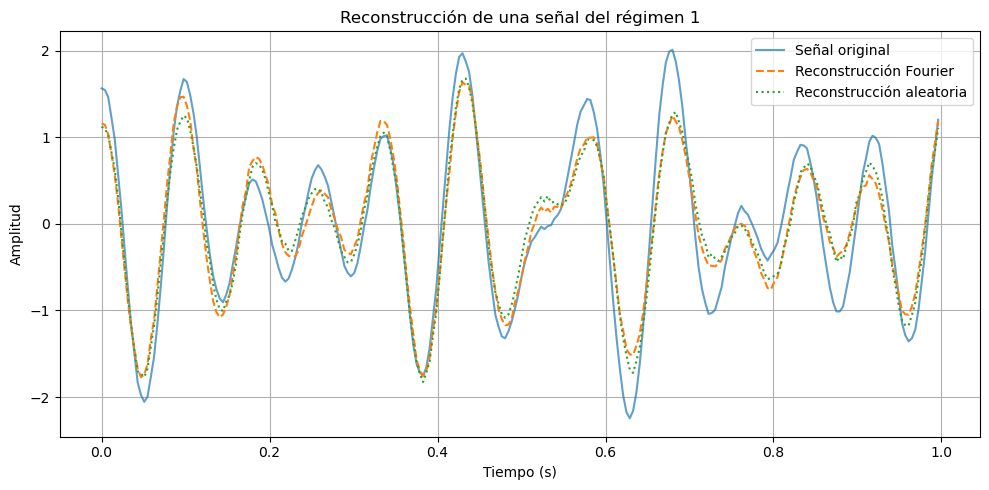

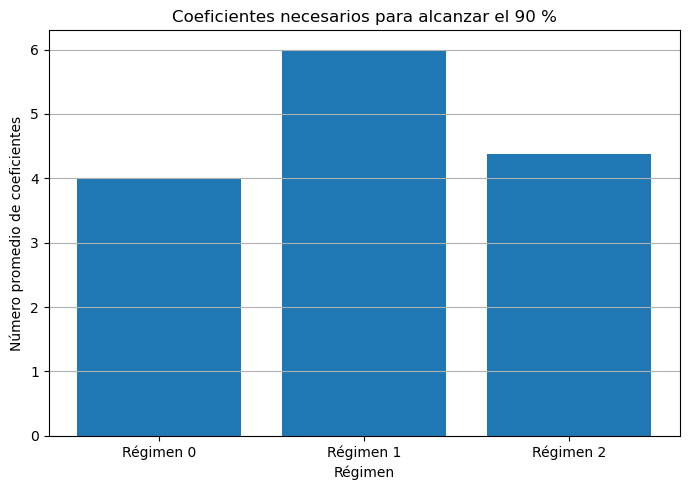

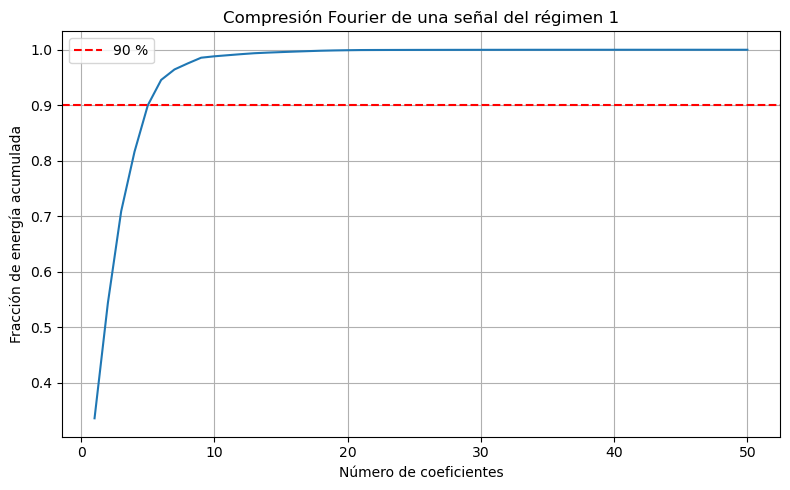

In [ ]:
# Gráfica 1: Evolución de la pérdida (escala lineal)
graficar_evolucion_perdida(
    historial_fourier, 
    historial_aleatorio, 
    escala_log=False, 
    titulo="Evolución de la pérdida"
)

# Gráfica 2: Evolución de la pérdida (escala logarítmica)
graficar_evolucion_perdida(
    historial_fourier, 
    historial_aleatorio, 
    escala_log=True, 
    titulo="Evolución de la pérdida en escala logarítmica"
)

# Gráfica 3: Velocidad de aprendizaje en régimen 2 (escala logarítmica)
graficar_evolucion_perdida(
    historial_regimen2_fourier, 
    historial_regimen2_aleatorio, 
    escala_log=True, 
    titulo="Velocidad de aprendizaje en el régimen 1"  # REVISAR: ajustado a foco=regimen 1
)

# Gráfica 4: Reconstrucción de la señal
graficar_reconstruccion(
    t,
    x_original, 
    x_reconstruida_fourier, 
    x_reconstruida_aleatoria, 
    indice_regimen=1  # REVISAR: ajustado a foco=regimen 1
)

# Gráfica 5: Coeficientes promedio para el 90%
graficar_barras_coeficientes(promedios_90, porcentaje=90)

# Gráfica 6: Compresión de energía Fourier
graficar_compresion_energia(energia_acumulada, K, porcentaje_ref=0.90)